<a href="https://colab.research.google.com/github/Salma53ster/Flash-Chat/blob/master/My_Assignment1_Process_Mining_PM4Py_BPI2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# My Assignment 1: Process Mining with PM4Py
BPI Challenge 2017 Dataset

In [ ]:
!pip install -q pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.7 MB/s eta 0:00:00


In [ ]:
import pm4py
from google.colab import files
uploaded = files.upload()
log_file=list(uploaded.keys())[0]
log=pm4py.read_xes(log_file)
print("Log Loaded Successfully")



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Saving BPI Challenge 2017.xes.gz to BPI Challenge 2017.xes.gz


/usr/local/lib/python3.13/dist-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Log Loaded Successfully


In [ ]:
num_cases = log['case:concept:name'].nunique()
num_events = len(log)
activities = set(log['concept:name'].unique())
print("Cases:",num_cases)
print("Events:",num_events)
print("Activities:",len(activities))

Cases: 31509
Events: 1202267
Activities: 26


In [ ]:
df=pm4py.convert_to_dataframe(log)
df=df.drop_duplicates()
df=df.sort_values(["case:concept:name","time:timestamp"])
event_log=pm4py.convert_to_event_log(df)

In [ ]:
import os
from pm4py.visualization.dfg import visualizer as dfg_visualizer
from pm4py.visualization.petri_net import visualizer as petri_visualizer

output_folder = "output_visualizations"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

# Save the DFG visualization
# Re-applying the visualizer to get the DFG graph object as 'gviz' was overwritten by the Petri Net visualization
dfg_gviz = dfg_visualizer.apply(dfg, log=event_log)
dfg_output_path = os.path.join(output_folder, "dfg_visualization.png")
dfg_visualizer.save(dfg_gviz, dfg_output_path)
print(f"DFG visualization saved to: {dfg_output_path}")

# Save the Petri Net visualization (the current 'gviz' variable holds this)
petri_net_output_path = os.path.join(output_folder, "petri_net_visualization.png")
petri_visualizer.save(gviz, petri_net_output_path)
print(f"Petri Net visualization saved to: {petri_net_output_path}")

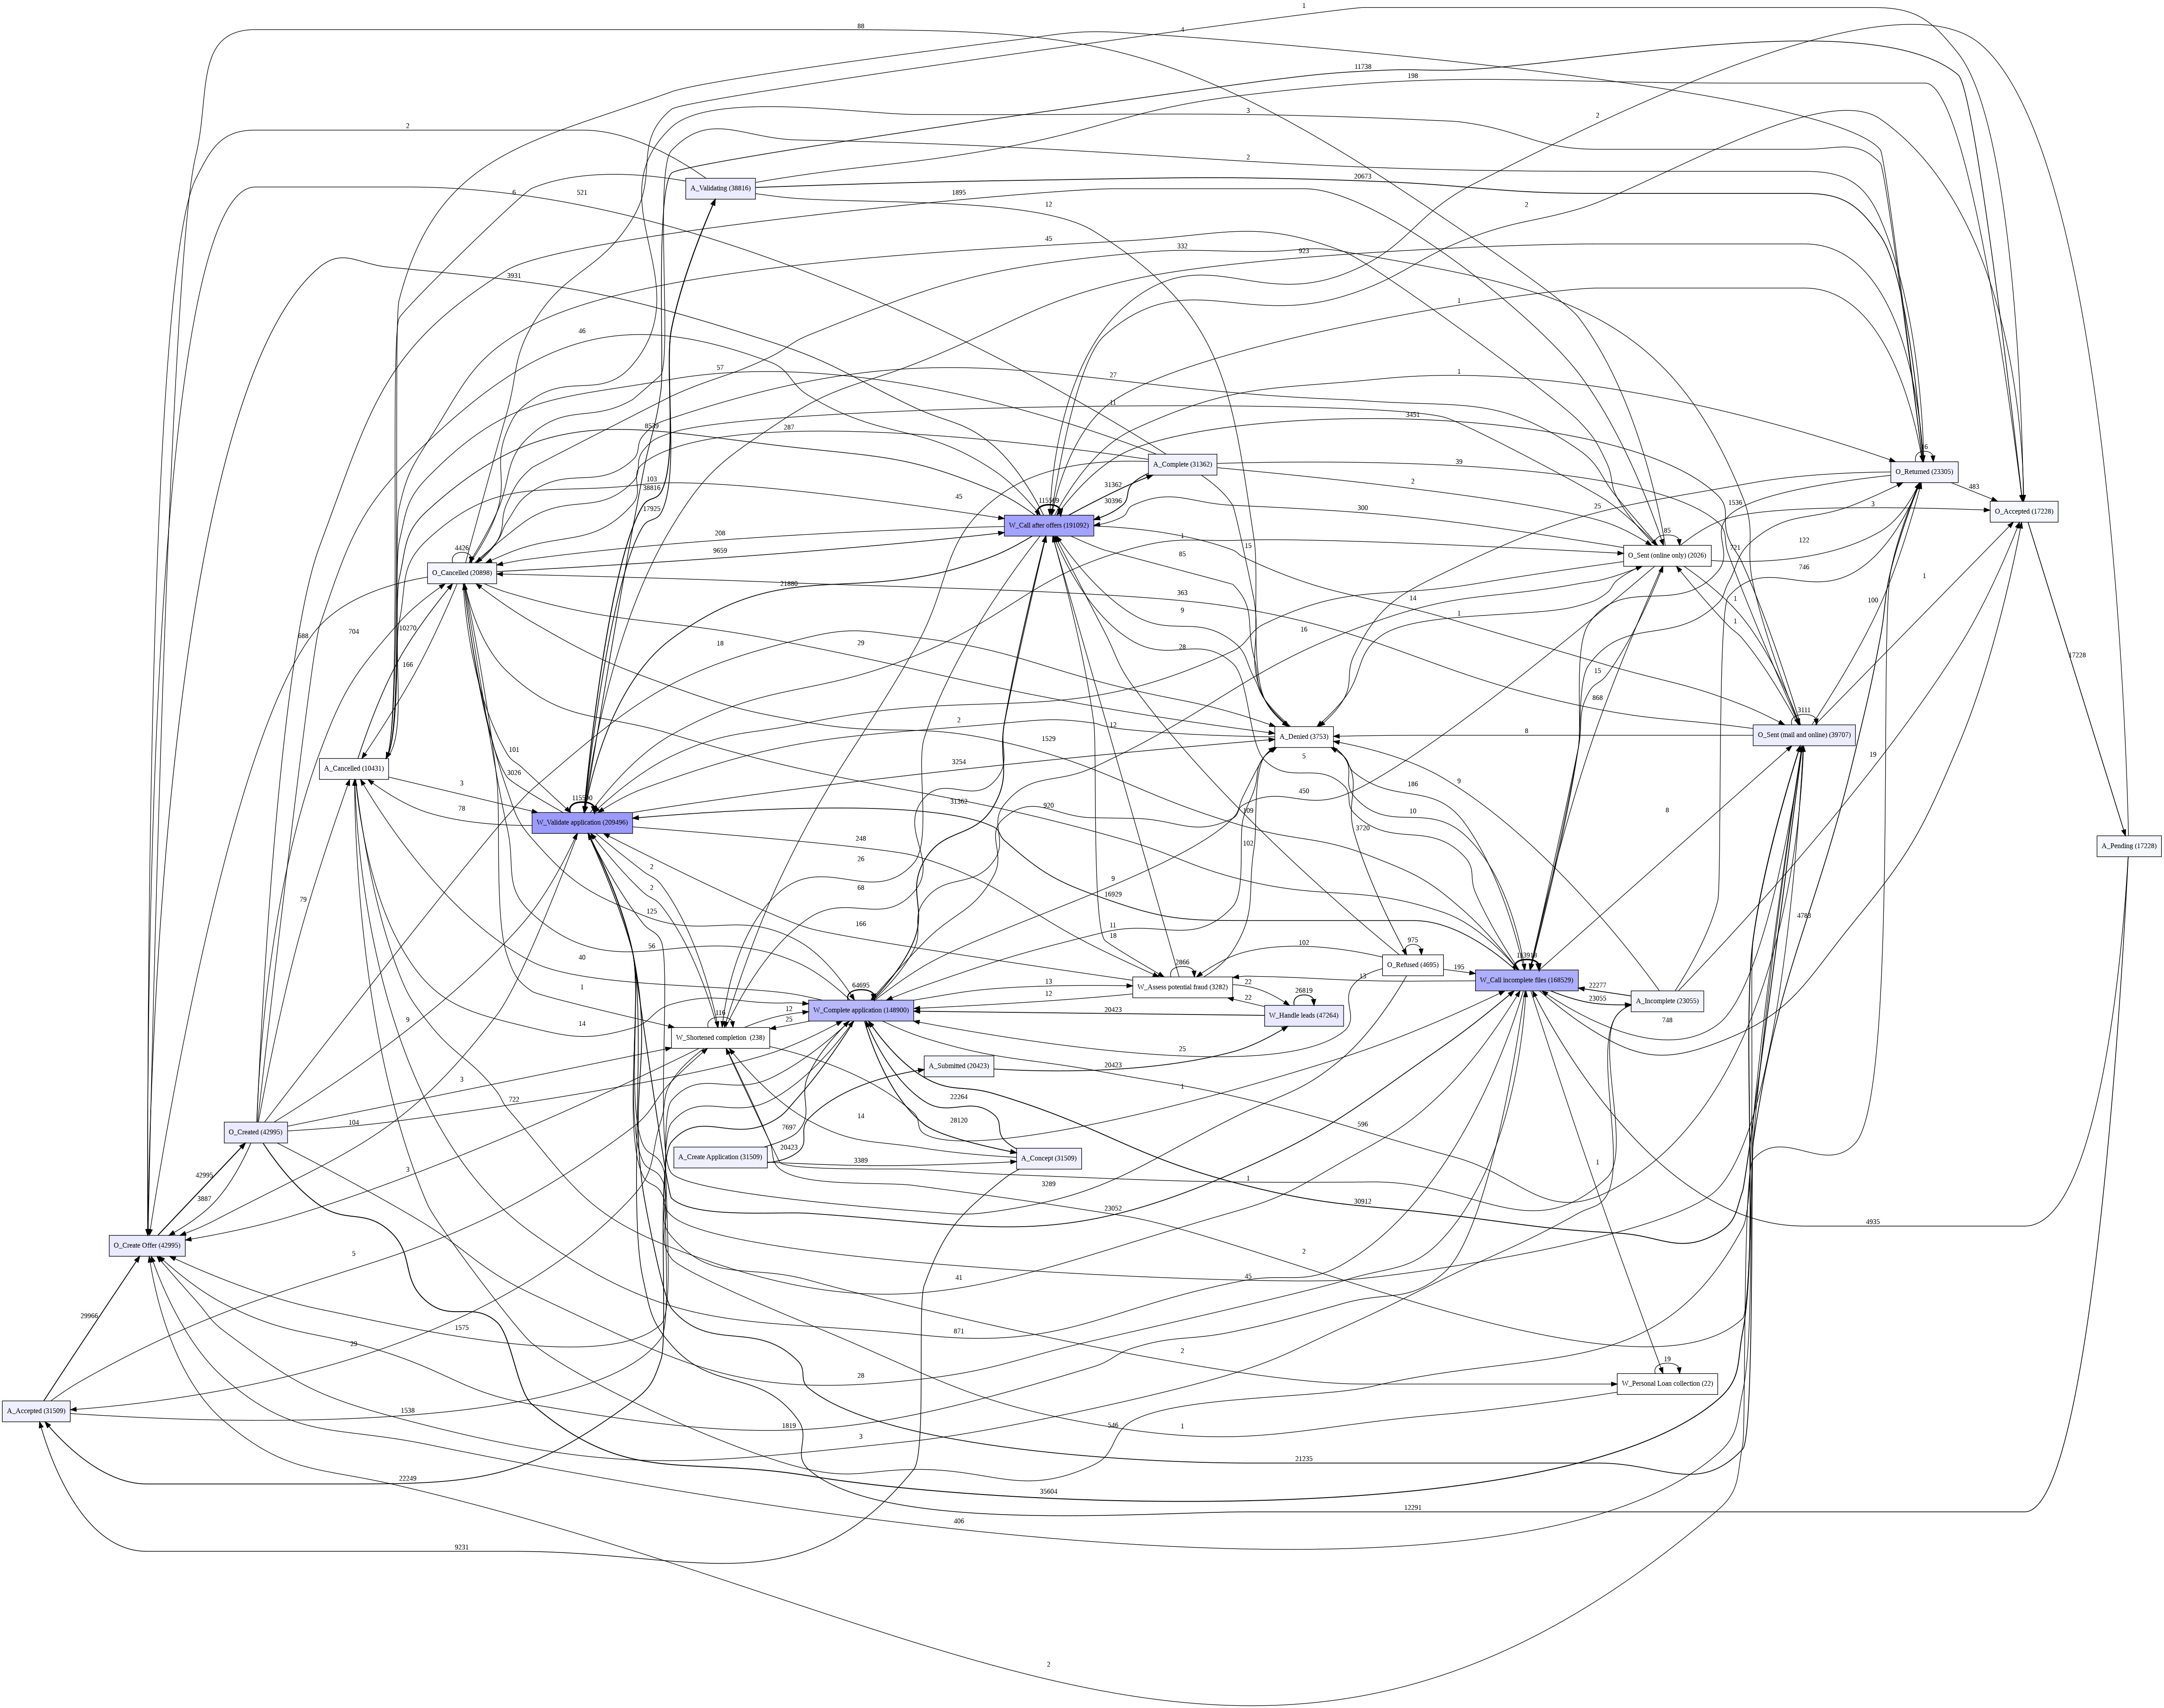

In [ ]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualizer
dfg=dfg_discovery.apply(event_log)
gviz=dfg_visualizer.apply(dfg,log=event_log)
dfg_visualizer.view(gviz)

### Save Visualizations to Output Folder

The following cell creates a new folder named `output_visualizations` (if it doesn't already exist) and then saves the generated DFG (Directly Follows Graph) and Petri Net visualizations as PNG image files within this folder. This allows you to easily access and share the visual outputs of the process mining analysis.

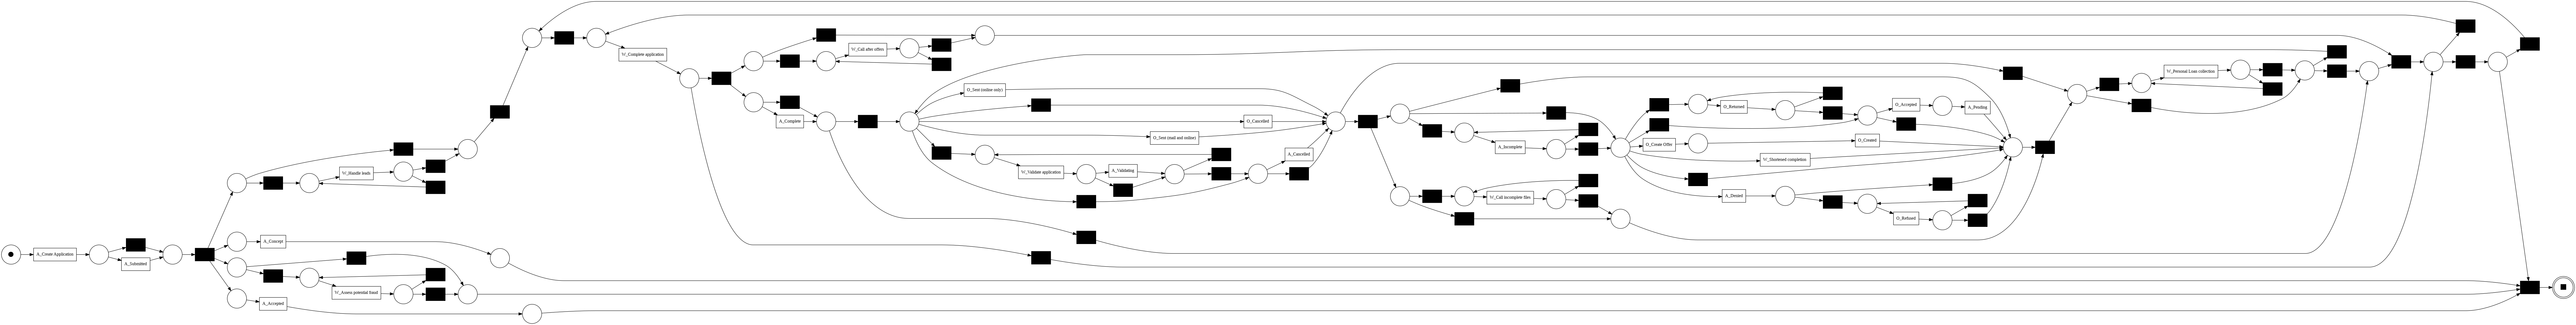

In [ ]:
net,im,fm=pm4py.discover_petri_net_inductive(event_log)
from pm4py.visualization.petri_net import visualizer
gviz=visualizer.apply(net,im,fm)
visualizer.view(gviz)

# **Graphviz BPMN-style Diagram (Recommended for Colab)**

In [ ]:
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph

bpmn = Digraph("AS_IS_Loan_Process")
bpmn.attr(rankdir="LR")
bpmn.attr("node", shape="box", style="rounded")

# Activities
bpmn.node("A1", "Submit Loan Application")
bpmn.node("A2", "Validate Application")
bpmn.node("A3", "Request Missing Information")
bpmn.node("A4", "Receive Additional Documents")
bpmn.node("A5", "Eligibility Check")
bpmn.node("A6", "Credit Assessment")
bpmn.node("A7", "Risk Assessment")
bpmn.node("A8", "Determine Loan Offer")
bpmn.node("A9", "Send Offer to Customer")
bpmn.node("A10", "Final Approval Review")
bpmn.node("A11", "Create Contract")
bpmn.node("A12", "Sign Contract")
bpmn.node("A13", "Disburse Loan")

# Start and End Events
bpmn.attr("node", shape="circle")
bpmn.node("Start", "")
bpmn.node("End1", "")
bpmn.node("End2", "")
bpmn.node("End3", "")

# Gateways
bpmn.attr("node", shape="diamond")

bpmn.node("G1", "Application\nComplete?")
bpmn.node("G2", "Creditworthy?")
bpmn.node("G3", "Offer\nAccepted?")
bpmn.node("G4", "Approved?")

# Flows
bpmn.edge("Start", "A1")
bpmn.edge("A1", "A2")
bpmn.edge("A2", "G1")

# Missing information loop
bpmn.edge("G1", "A3", label="No")
bpmn.edge("A3", "A4")
bpmn.edge("A4", "A2")

# Complete
bpmn.edge("G1", "A5", label="Yes")

bpmn.edge("A5", "A6")
bpmn.edge("A6", "A7")
bpmn.edge("A7", "G2")

# Rejection
bpmn.edge("G2", "End1", label="No")

# Approved
bpmn.edge("G2", "A8", label="Yes")
bpmn.edge("A8", "A9")
bpmn.edge("A9", "G3")

# Offer rejected
bpmn.edge("G3", "End2", label="No")

# Offer accepted
bpmn.edge("G3", "A10", label="Yes")
bpmn.edge("A10", "G4")

# Final approval rejected
bpmn.edge("G4", "End3", label="No")

# Final approval accepted
bpmn.edge("G4", "A11", label="Yes")
bpmn.edge("A11", "A12")
bpmn.edge("A12", "A13")
bpmn.edge("A13", "End3")

bpmn.render("AS_IS_BPMN_Model", format="png", cleanup=False)

from IPython.display import Image
Image("AS_IS_BPMN_Model.png")


In [ ]:
variants=pm4py.get_variants(event_log)
print("Total Variants:",len(variants))

Total Variants: 15930


## Top 10 *Variants* **

In [ ]:
# =====================================================
# TOP VARIANTS
# =====================================================

variant_frequency = {
    str(v): len(cases)
    for v, cases in variants.items()
}

sorted_variants = sorted(
    variant_frequency.items(),
    key=lambda x: x[1],
    reverse=True
)

for i, (variant, count) in enumerate(sorted_variants[:10],1):

    print("\nVariant",i)
    print("Frequency:",count)
    print(variant)

NameError: name 'variants' is not defined

In [ ]:
import pm4py
import pandas as pd

# Ensure log_file is defined and pointing to the correct file
log_file = '/content/BPI Challenge 2017.xes.gz'
print(f"Using log file: {log_file}")

# Always load the log to ensure it's not None
print("Loading log from file...")
log = pm4py.read_xes(log_file)

# Always convert to DataFrame and Event Log
print("Converting log to DataFrame and Event Log...")
df = pm4py.convert_to_dataframe(log)
df = df.drop_duplicates()
df = df.sort_values(["case:concept:name", "time:timestamp"])
event_log = pm4py.convert_to_event_log(df)

# Always discover the Petri Net
print("Discovering Petri Net...")
net, im, fm = pm4py.discover_petri_net_inductive(event_log)

# Proceed with fitness and precision calculations
fitness = pm4py.fitness_token_based_replay(event_log, net, im, fm)
precision = pm4py.precision_token_based_replay(event_log, net, im, fm)
print("Fitness:", fitness)
print("Precision:", precision)

Using log file: /content/BPI Challenge 2017.xes.gz
Loading log from file...


/usr/local/lib/python3.13/dist-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Converting log to DataFrame and Event Log...
Discovering Petri Net...


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

# **Fitness Evaluation**

In [ ]:
# =====================================================
# FITNESS
# =====================================================

fitness = pm4py.fitness_token_based_replay(
    event_log,
    net,
    im,
    fm
)

print(fitness)

NameError: name 'pm4py' is not defined

# **Precision Evaluation**

In [ ]:
# =====================================================
# PRECISION
# =====================================================

precision = pm4py.precision_token_based_replay(
    event_log,
    net,
    im,
    fm
)

print("Precision =", precision)


# **Throughput Time Analysis**

In [ ]:
# =====================================================
# CASE DURATION
# =====================================================

import pandas as pd
import pm4py

# Ensure log_file is defined
if 'log_file' not in globals():
    log_file = '/content/BPI Challenge 2017.xes.gz'
    print(f"'log_file' not found in globals, setting to: {log_file}")

# Ensure log is loaded
if 'log' not in globals():
    print("Loading log from file...")
    log = pm4py.read_xes(log_file)

# Ensure df is created
if 'df' not in globals():
    print("Converting log to DataFrame...")
    df = pm4py.convert_to_dataframe(log)
    df = df.drop_duplicates()
    df = df.sort_values(["case:concept:name", "time:timestamp"])

throughput = []

for case_id, case in df.groupby(
    "case:concept:name"
):

    duration_days = (
        case["time:timestamp"].max()
        -
        case["time:timestamp"].min()
    ).total_seconds() / 86400

    throughput.append(duration_days)

throughput_df = pd.DataFrame(
    throughput,
    columns=["Duration_Days"]
)

throughput_df.describe()



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




'log_file' not found in globals, setting to: /content/BPI Challenge 2017.xes.gz
Loading log from file...


/usr/local/lib/python3.13/dist-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Converting log to DataFrame...


,Duration_Days
count,31509.000000
mean,21.899606
std,13.169233
min,0.002327
25%,11.324672
50%,19.087739
75%,31.495729
max,286.072438


# **Throughput Time Histogram**

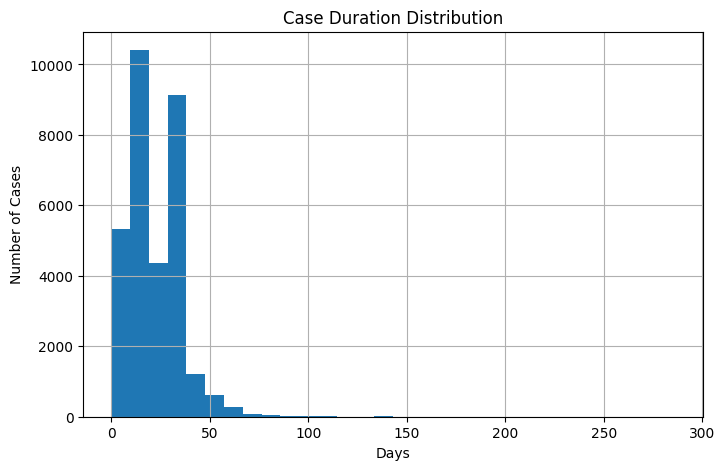

In [ ]:
# =====================================================
# HISTOGRAM
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

throughput_df["Duration_Days"].hist(
    bins=30
)

plt.title("Case Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Cases")

plt.show()

# **Activity Frequency Analysis**

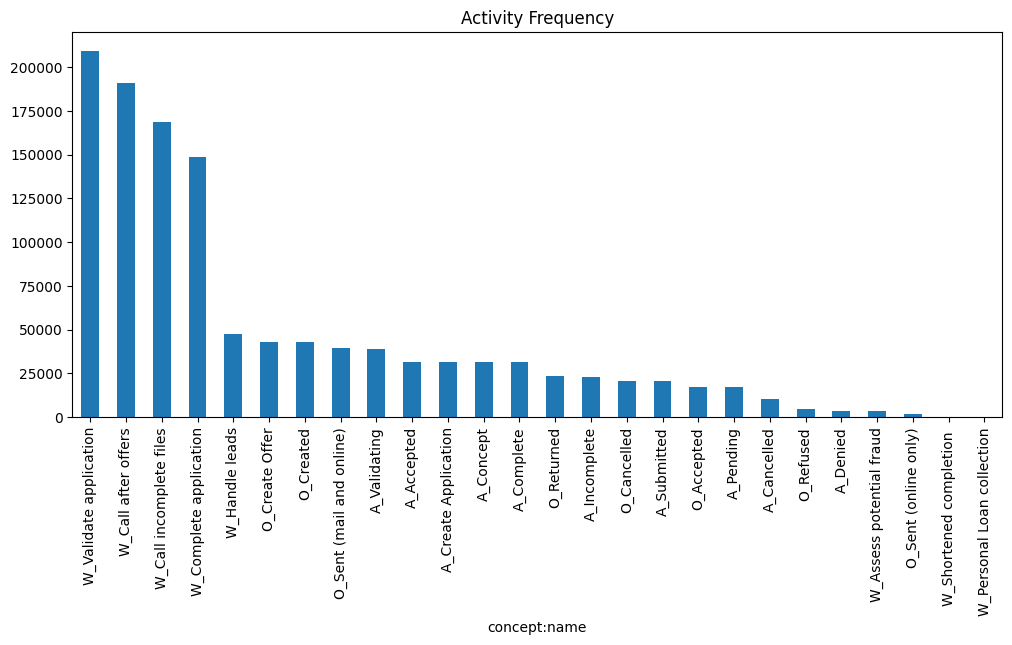

In [ ]:
# =====================================================
# ACTIVITY FREQUENCY CHART
# =====================================================

import matplotlib.pyplot as plt

# Calculate activity frequency
activity_freq = df["concept:name"].value_counts()

activity_freq.plot.bar(
    figsize=(12,5)
)

plt.title("Activity Frequency")
plt.show()

# **Activity Frequency Chart**

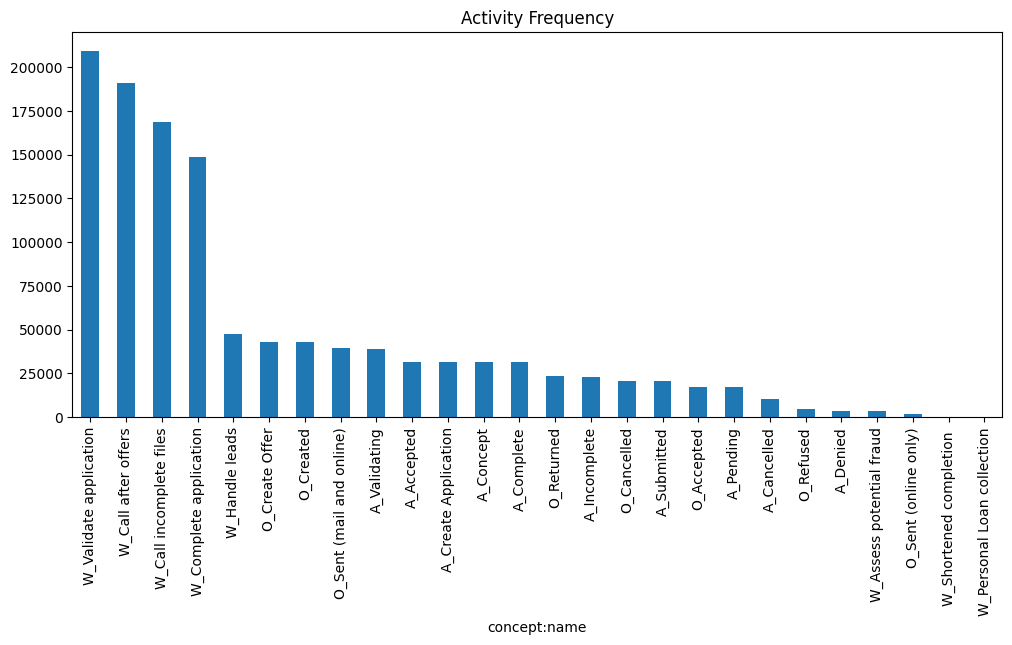

In [ ]:
# =====================================================
# ACTIVITY FREQUENCY CHART
# =====================================================

activity_freq.plot.bar(
    figsize=(12,5)
)

plt.title("Activity Frequency")
plt.show()

# **Rework Analysis**

In [ ]:
# =====================================================
# REWORK ANALYSIS
# =====================================================

rework_cases = 0

for cid, case in df.groupby(
    "case:concept:name"
):

    acts = list(
        case["concept:name"]
    )

    if len(acts) != len(set(acts)):
        rework_cases += 1

print(
    "Cases with Rework:",
    rework_cases
)

Cases with Rework: 31509


# **Resource Workload Analysis**

In [ ]:
# =====================================================
# RESOURCE ANALYSIS
# =====================================================

resource_col = "org:resource"

if resource_col in df.columns:

    resource_load = (
        df[resource_col]
        .value_counts()
    )

    print(resource_load.head(20))

org:resource
User_1      148404
User_3       26342
User_5       22900
User_87      22498
User_30      21272
User_49      21134
User_123     20909
User_29      20860
User_100     20651
User_2       19134
User_27      18806
User_121     18726
User_28      18412
User_68      17581
User_116     17423
User_10      16365
User_113     16151
User_118     16005
User_75      15955
User_41      15481
Name: count, dtype: int64


# **Resource Workload Chart**

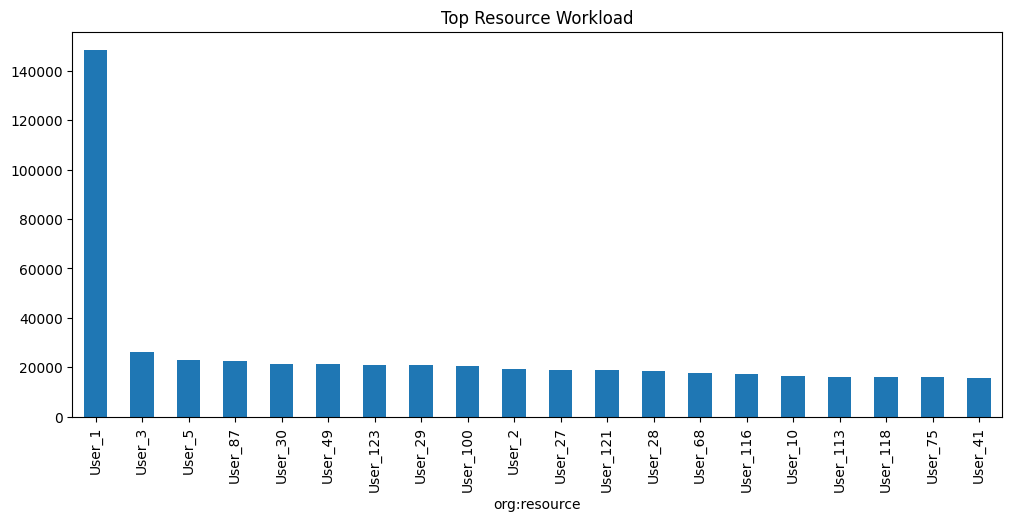

In [ ]:
# =====================================================
# RESOURCE WORKLOAD
# =====================================================

resource_load.head(20).plot.bar(
    figsize=(12,5)
)

plt.title(
    "Top Resource Workload"
)

plt.show()

# **Process Complexity**

In [ ]:
# =====================================================
# PROCESS COMPLEXITY
# =====================================================

import pm4py

# Ensure df is created (it should be from previous cells, but add a check for robustness)
# If df is not defined, we would likely get an error before this, but good practice
if 'df' not in globals():
    print("Warning: 'df' not found. Please ensure previous cells defining 'df' are executed.")
    # Attempt to load from log if log is present and df is not
    if 'log' in globals() and 'log' is not None:
        df = pm4py.convert_to_dataframe(log)
        df = df.drop_duplicates()
        df = df.sort_values(["case:concept:name", "time:timestamp"])

# Ensure event_log is created
if 'event_log' not in globals() and 'df' in globals():
    print("Converting df to event_log...")
    event_log = pm4py.convert_to_event_log(df)

# Ensure variants is calculated only if event_log is available
if 'event_log' in globals():
    variants = pm4py.get_variants(event_log)
    print(
        "Number of Variants:",
        len(variants)
    )
else:
    print("Error: 'event_log' could not be created, unable to calculate variants.")

<>:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
/tmp/ipykernel_45123/1865383369.py:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if 'log' in globals() and 'log' is not None:


Converting df to event_log...
Number of Variants: 15930


# **Conformance Checking**

In [ ]:
# =====================================================
# TOKEN REPLAY
# =====================================================

import pm4py

# Ensure event_log is created (assuming 'df' is available from previous steps)
if 'event_log' not in globals():
    if 'df' in globals():
        print("Converting df to event_log...")
        event_log = pm4py.convert_to_event_log(df)
    else:
        print("Error: 'df' not found. Cannot create event_log.")

# Ensure net, im, fm are discovered
if 'net' not in globals() or 'im' not in globals() or 'fm' not in globals():
    if 'event_log' in globals():
        print("Discovering Petri Net...")
        net, im, fm = pm4py.discover_petri_net_inductive(event_log)
    else:
        print("Error: 'event_log' not found. Cannot discover Petri Net.")

# Only proceed with token replay if all necessary variables are defined
if 'event_log' in globals() and 'net' in globals() and 'im' in globals() and 'fm' in globals():
    token_result = pm4py.conformance_diagnostics_token_based_replay(
        event_log,
        net,
        im,
        fm
    )

    print(
        token_result[:5]
    )
else:
    print("Token replay cannot be performed due to missing dependencies.")

Discovering Petri Net...


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

[{'trace_is_fit': True, 'trace_fitness': 1.0, 'activated_transitions': [(9a6d438c-4a08-44e8-b67e-52e77d94e3ae, 'A_Create Application'), (4f78ac06-9aaf-447c-8bed-762492a05e2e, 'A_Submitted'), (tauSplit_3, None), (init_loop_11, None), (c3580cbf-1149-45de-84b3-f5f7217c00d0, 'W_Handle leads'), (skip_13, None), (c3580cbf-1149-45de-84b3-f5f7217c00d0, 'W_Handle leads'), (skip_14, None), (init_loop_15, None), (init_loop_17, None), (45a7ca84-bf25-4145-ab0b-24d12017aeae, 'W_Complete application'), (1435a14c-c97f-4497-b6b3-7d918719f889, 'A_Concept'), (skip_19, None), (skip_72, None), (45a7ca84-bf25-4145-ab0b-24d12017aeae, 'W_Complete application'), (skip_19, None), (skip_72, None), (45a7ca84-bf25-4145-ab0b-24d12017aeae, 'W_Complete application'), (305d9e4a-eed4-44bb-a54f-09bbf6eae911, 'A_Accepted'), (tauSplit_20, None), (skip_27, None), (init_loop_29, None), (skip_31, None), (tauSplit_40, None), (skip_48, None), (4231d2b8-e894-4f96-ac17-2ef2522d4379, 'O_Create Offer'), (86086647-3fdd-4608-be09-10

# **Count Non-Conforming Cases**

In [ ]:
# =====================================================
# VIOLATIONS
# =====================================================

violations = 0

for result in token_result:

    if not result["trace_is_fit"]:
        violations += 1

print(
    "Violating Cases:",
    violations
)

print(
    "Violation Percentage:",
    round(
        violations /
        len(event_log) *
        100,
        2
    ),
    "%"
)

# **Alignment-Based Conformance Checking**

In [ ]:
# =====================================================
# ALIGNMENTS
# =====================================================

from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

alignment_result = alignments.apply_log(
    event_log,
    net,
    im,
    fm
)

print(
    alignment_result[:5]
)

aligning log, completed variants ::   0%|          | 0/15930 [00:00<?, ?it/s]

# **Bottleneck Analysis**

In [ ]:
# =====================================================
# BOTTLENECK ANALYSIS
# =====================================================

df["next_activity"] = (
    df.groupby("case:concept:name")
    ["concept:name"]
    .shift(-1)
)

df["next_time"] = (
    df.groupby("case:concept:name")
    ["time:timestamp"]
    .shift(-1)
)

df["waiting_hours"] = (
    (
        df["next_time"]
        -
        df["time:timestamp"]
    )
    .dt.total_seconds()
    / 3600
)

bottlenecks = (
    df.groupby("concept:name")
    ["waiting_hours"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(
    bottlenecks.head(10)
)

# **Bottleneck Visualization**

# **Bottleneck Visualization**

In [ ]:
# =====================================================
# BOTTLENECK CHART
# =====================================================

bottlenecks.head(10).plot.bar(
    figsize=(10,5)
)

plt.title(
    "Top Bottleneck Activities"
)

plt.ylabel(
    "Average Waiting Hours"
)

plt.show()

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
throughput=[]
for cid,case in df.groupby("case:concept:name"):
    throughput.append((case["time:timestamp"].max()-case["time:timestamp"].min()).total_seconds()/86400)
pd.DataFrame(throughput,columns=["Duration_Days"]).describe()

In [ ]:
activity_freq=df["concept:name"].value_counts()
activity_freq.plot.bar(figsize=(12,5))
plt.show()

In [ ]:
token_result=pm4py.conformance_diagnostics_token_based_replay(event_log,net,im,fm)
violations=sum(1 for r in token_result if not r["trace_is_fit"])
print("Violations:",violations)

# **Improvement Opportunities Report**

In [ ]:
# =====================================================
# IMPROVEMENT OPPORTUNITIES
# =====================================================

print("=== RECOMMENDATIONS ===\n")

print(
    "1. Automate high-frequency activities."
)

print(
    "2. Reduce bottlenecks identified above."
)

print(
    "3. Investigate non-conforming cases."
)

print(
    "4. Standardize common variants."
)

print(
    "5. Balance workload among resources."
)

print(
    "6. Reduce rework loops."
)

In [ ]:
print("Improvement opportunities: automate high-frequency activities, reduce bottlenecks, investigate non-conforming cases, standardize variants.")